# EDS 232 Machine Learning Competition (2026)
Sofia Sarak and Isabella Segarra 

## Background

This notebook contains a submission to the [EDS232: Machine Learning for Environmental Science](https://meds-eds-232.github.io/EDS-232-course-website/) Kaggle competition. In it, students compete to develop machine learning models that produce the lowest Mean Squared Error (MSE) for a specific dataset.

### Data

This competition uses data from the [California Cooperative Oceanic Fisheries Investigations (CalCOFI)](https://calcofi.org/) program, which is one of the longest-running oceanographic time series in the world. Data comes from seawater samples collected off of the California coast. Dissolved inorganic carbon (DIC) is the response variable and sea water temperature, alkalinity, depth, and salinity are the predictors. Not all predictor variables have to be used in the final models.

As part of the competiton, we were provided with a training and test set of these variables. Submission to the Kaggle competition requires a dataframe that contains only id and predicted DIC as columns.

## Setup

In [ ]:
# import necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

In [2]:
# import training and test sets
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

## Exploratory Data Analysis

In [3]:
# view variables and their data types
train.dtypes

id                  int64
CTDTEMP_ITS90     float64
Salinity_PSS78    float64
Depth             float64
TA                float64
DIC               float64
dtype: object

In [ ]:
# view first few rows of df
train.head(3)

,id,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA,DIC
0,0,15.36,33.6095,10.0,2241.0,1989.4
1,1,11.23,33.6095,10.0,2241.0,1989.8
2,2,11.23,33.6095,10.0,2241.0,1989.3


In [19]:
# explore the number of missing values for each column
train.isna().sum()

id                0
CTDTEMP_ITS90     0
Salinity_PSS78    0
Depth             0
TA                0
DIC               0
dtype: int64

#### Exploring distributions of predictors

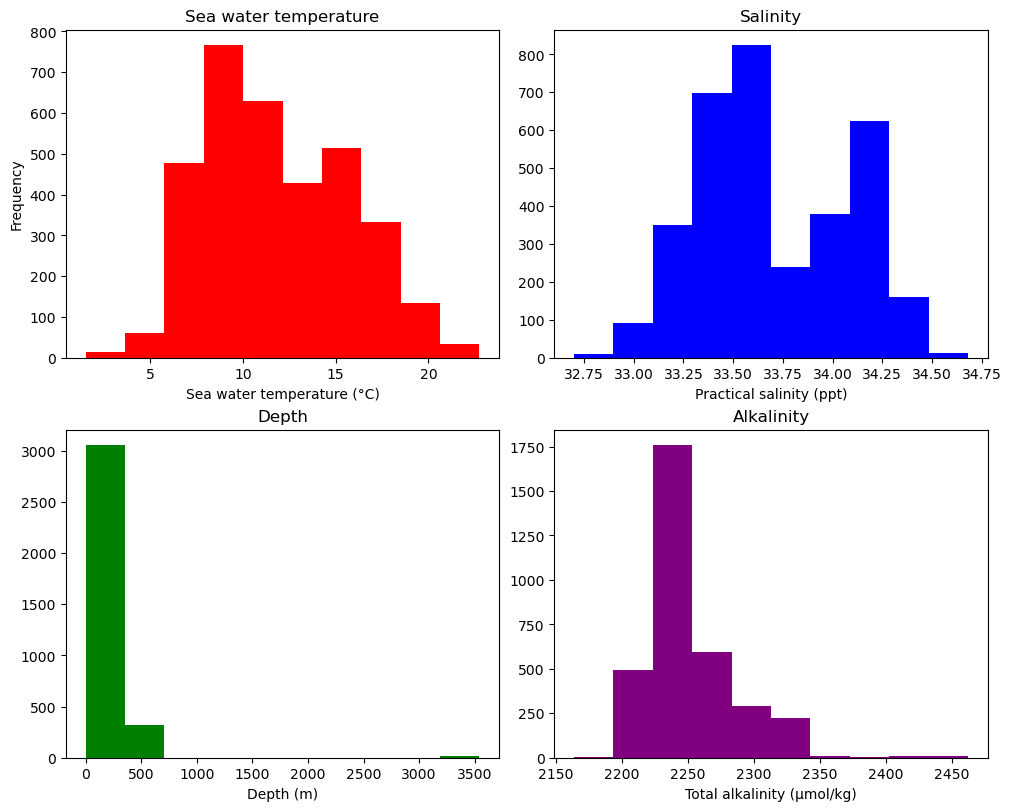

In [23]:
# initialize figure
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), layout = "constrained")

# sea water temp plot
axes[0,0].hist(train['CTDTEMP_ITS90'], color = 'red')
axes[0,0].set_xlabel('Sea water temperature (°C)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Sea water temperature')

# salinity plot
axes[0,1].hist(train['Salinity_PSS78'], color = 'blue')
axes[0,1].set_xlabel('Practical salinity (ppt)')
axes[0,0].set_ylabel('Frequency')
axes[0,1].set_title('Salinity')

# depth plot
axes[1,0].hist(train['Depth'], color = 'green')
axes[1,0].set_xlabel('Depth (m)')
axes[0,0].set_ylabel('Frequency')
axes[1,0].set_title('Depth')

# alkalinity plot
axes[1,1].hist(train['TA'], color = 'purple')
axes[1,1].set_xlabel('Total alkalinity (µmol/kg)')
axes[0,0].set_ylabel('Frequency')
axes[1,1].set_title('Alkalinity')

plt.show()

#### Distribution Observations

Sea water temperature has a relatively normal distribution. Salinity can be described as bimodal. Depth has a few very high outliers, skewing the distribution. Alkalinity is has a right-skewed distribution.

#### Explore relationship between four predictors to response (DIC)

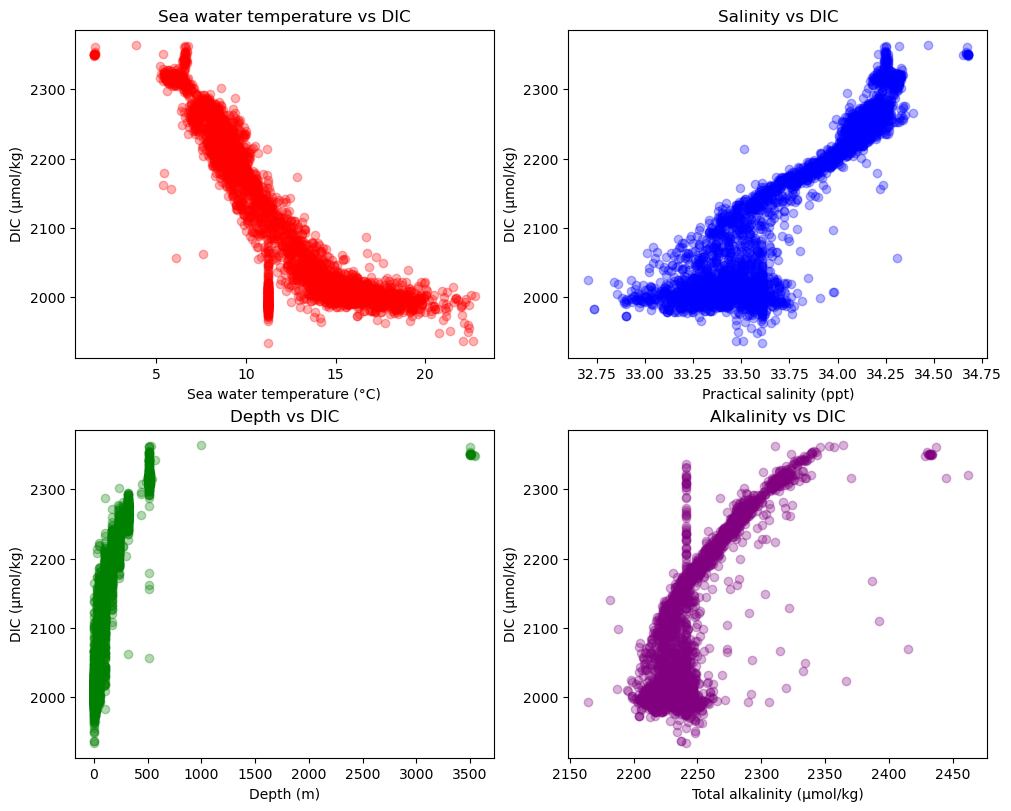

In [ ]:
# initialize figure
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), layout = "constrained")

# sea water temp plot
axes[0,0].scatter(train['CTDTEMP_ITS90'], train['DIC'], alpha = 0.3, color = 'red')
axes[0,0].set_xlabel('Sea water temperature (°C)')
axes[0,0].set_ylabel('DIC (µmol/kg)')
axes[0,0].set_title('Sea water temperature vs DIC')

# salinity plot
axes[0,1].scatter(train['Salinity_PSS78'], train['DIC'], alpha = 0.3, color = 'blue')
axes[0,1].set_xlabel('Practical salinity (ppt)')
axes[0,1].set_ylabel('DIC (µmol/kg)')
axes[0,1].set_title('Salinity vs DIC')

# depth plot
axes[1,0].scatter(train['Depth'], train['DIC'], alpha = 0.3, color = 'green')
axes[1,0].set_xlabel('Depth (m)')
axes[1,0].set_ylabel('DIC (µmol/kg)')
axes[1,0].set_title('Depth vs DIC')

# alkalinity plot
axes[1,1].scatter(train['TA'], train['DIC'], alpha = 0.3, color = 'purple')
axes[1,1].set_xlabel('Total alkalinity (µmol/kg)')
axes[1,1].set_ylabel('DIC (µmol/kg)')
axes[1,1].set_title('Alkalinity vs DIC')

plt.show()

## Models

### Model 1: Random Forest

### Model 2

## Summary 